## Plan de déroulement des étapes de pre-processing et de modelisation: :

* Création d'un graphique avec toutes les informations statistiques des données MvTec
  - ci les pieces sont des textures ou des objects.
  - le nombre des images de train, de test(good) et test (anomalie)
  - **creation d'une boite à moustache pour visualiser la distribution des tailles des anomalies de chaque pieces (cela peut-impacter le redimenssionnement des images)**
  -

# Etape de modilisation:
 #####  on fera un modele avec un reseau de neurone simple pour l'ensemble des categorie:


In [37]:
!pip install -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 3.0 MB/s eta 0:00:00


In [38]:
## import des librairie necessaires :

import os
import cv2
import numpy as np
from glob import glob
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from imblearn.metrics import classification_report_imbalanced, geometric_mean_score
from sklearn.metrics import f1_score
import pandas as pd
from sklearn.preprocessing import StandardScaler
from collections import Counter
import seaborn as sns
import tensorflow as tf
from sklearn.neural_network import MLPClassifier

from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.model_selection import RandomizedSearchCV
from skopt import BayesSearchCV
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Preprocessing:

Dans cette partie nous allors appliquer des preprocessing basique à notre jeux de données.

Pour le premier modele nous allons effectuer une classification non supervisé. on utilisera uniquement les données train good pour entrainner le modele et les données test sans good pour tester le modele.

Comme vu dans la partie de l'exploration des données, les images de notre dataset on différentes taille, et des images en couleurs et gris .


* Comme les reseau de neuronne utilise que les images avec la même taille nous allors redimensionner les image de notre jeux de données en entier.
* Aussi, nous allons lire toute les image en couleurs car si on convertis les images en gris  on risque de perdre l'information de la couleurs.
* on normalise aussi les image de 0 et 1 car les reseau de neuronne sont sensible à l'echelle d'entrée. Cette étape est indispensable afin de permet au reseau de neuronne de travailler sur des gradiant initiaux de petite valeurs. aussi certaine fonction d'activation comme sigmoid ont une mielleurs performance avec des données normaliser. et aussi certain fonction d'optimisation travaille mieux avec des données normalisé.


###### **`Fonction pour preprocessing:`**

In [ ]:
## Fonction qui permet de faire les preprocessing necessaires pour l'ensemble des données du dataset:

def preprocessing_all (path, color_mode='rgb'):

    """ Fonction qui permet de faire les preprocessing basique pour lancer un modele de reseau de neuronne
      les argument:
            path: le chemin de l'emplacement des données
            color_mode = 'rgb': convertir toute les image en RGB même les images initialement en gris
                         afin de ne pas perdre l'information de la couleurs.

            Normalise: on normalise les images en remplacant tout les pixels avec des valeurs de 0 à 1
              """

    ## stocker les images prétraité:
    img_prp= []
    ##lire tout les images de dataset
    img_paths = glob(os.path.join(path, "**", "*.*"), recursive=True)

    ## afficher le nombre d'image trouver par categorie:
    print(f"Nombre d'images trouvées dans {path} : {len(img_paths)}")

    for file_path in img_paths:

        ## Lire et modifier l'image la couleur de gray en RGB:
        if color_mode == 'rgb':
            img = cv2.imread(file_path, cv2.IMREAD_COLOR)
            if img is None:
                continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        else:
            img = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue
            img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

        ##redimentionnement des taille:
        img=cv2.resize(img, (256,256) )


        ##Normalisation:
        img=img.astype('float32')/255.

        ##ajouter le resultats dans la liste :
        img_prp.append(img)




    ##convertir la liste en tableau numpy:
    X = np.array(img_prp)


    return X




###### **`Création de X_train et y_train pour l'ensembel du dataset:`**

Dans cett partie, nous avons traité l'ensemble des catégroie de dataset afin de regrouper les image avec et sans anoamlies et créer les labels 0 pour sans anomalie et 1 avec anoamalies:

In [ ]:
##Appliquer les preprocessing pour l'ensemble des données de train/ good:

## pour cela nous allons utiliser la methode glob pour lire les fichier de train de l'ensemble des pieces :

path= r"C:/Users/hanou/OneDrive/Formation_DS/Projet/mvtec_anomaly_detection/*/train/good"
train_path= glob(path)

X_train_good= []
y_train_good=[]
for category_path in train_path:
    X_cate= preprocessing_all(category_path)
    y_anom = np.zeros(len(X_cate), dtype=np.int64)
    X_train_good.append(X_cate)
    y_train_good.append(y_anom)

X_train_good= np.concatenate(X_train_good, axis=0)
X_train_good= np.concatenate(y_train_good, axis=0)



Nombre d'images trouvées dans C:/Users/hanou/OneDrive/Formation_DS/Projet/mvtec_anomaly_detection\bottle\train\good : 209
Nombre d'images trouvées dans C:/Users/hanou/OneDrive/Formation_DS/Projet/mvtec_anomaly_detection\cable\train\good : 224
Nombre d'images trouvées dans C:/Users/hanou/OneDrive/Formation_DS/Projet/mvtec_anomaly_detection\capsule\train\good : 219
Nombre d'images trouvées dans C:/Users/hanou/OneDrive/Formation_DS/Projet/mvtec_anomaly_detection\carpet\train\good : 280
Nombre d'images trouvées dans C:/Users/hanou/OneDrive/Formation_DS/Projet/mvtec_anomaly_detection\grid\train\good : 264
Nombre d'images trouvées dans C:/Users/hanou/OneDrive/Formation_DS/Projet/mvtec_anomaly_detection\hazelnut\train\good : 391
Nombre d'images trouvées dans C:/Users/hanou/OneDrive/Formation_DS/Projet/mvtec_anomaly_detection\leather\train\good : 245
Nombre d'images trouvées dans C:/Users/hanou/OneDrive/Formation_DS/Projet/mvtec_anomaly_detection\metal_nut\train\good : 220
Nombre d'images trou

In [ ]:
print(X_train.shape)
print(X_train.dtype)


(3629, 256, 256, 3)
float32


###### **`Création de X_test et y_test pour l'ensemble du dataset:`**


In [ ]:
## liste pour stocker X_test et y_test
X_test= []
y_test= []


## chemin du dataset:
path= r"C:/Users/hanou/OneDrive/Formation_DS/Projet/mvtec_anomaly_detection"

## création du chemin pour chaque categorie du dataset MVTec
categories= glob(path+ "/*")

##faire une boucle pour créer
for cat in categories:
    test_path = cat + "/test"
    if not os.path.exists(test_path): ##verifier si une categorie n'a pas de dossier
        continue

    # GOOD → label 0
    good_path = test_path + "/good"
    if os.path.exists(good_path):
        X_good = preprocessing_all(good_path)  ##appliquer les preprocessing au données de test/good
        y_good = np.zeros(len(X_good), dtype=np.int64)  ## création d'un label 0 pour les données good et les stocker dans y_test
        X_test.append(X_good)
        y_test.append(y_good)

    # ANOMALIES → label 1
    for anomaly in os.listdir(test_path):
        if anomaly == "good":  ##on ignore le dossier good car on l'avait déja traité et stocker.
            continue

        ## création d'un nouveau path pour l'ensemble des anomalie de chauq piéces
        anomaly_path = test_path + "/" + anomaly
        if os.path.isdir(anomaly_path):  ## on verifier que c'est bien un dossier.
            X_anom = preprocessing_all(anomaly_path)  ## on applique les preprocessing instancier dans la focntion preprocessing_all
            y_anom = np.ones(len(X_anom), dtype=np.int64)  ## on ajoute un label au image avec anomalie de valeur 1
            X_test.append(X_anom)
            y_test.append(y_anom)

##faire la concaténation pour créer X_test et y_test final
X_test = np.concatenate(X_test, axis=0)
y_test = np.concatenate(y_test, axis=0)

print(X_test.shape, y_test.shape)


Nombre d'images trouvées dans C:/Users/hanou/OneDrive/Formation_DS/Projet/mvtec_anomaly_detection\bottle/test/good : 20
Nombre d'images trouvées dans C:/Users/hanou/OneDrive/Formation_DS/Projet/mvtec_anomaly_detection\bottle/test/broken_large : 20
Nombre d'images trouvées dans C:/Users/hanou/OneDrive/Formation_DS/Projet/mvtec_anomaly_detection\bottle/test/broken_small : 22
Nombre d'images trouvées dans C:/Users/hanou/OneDrive/Formation_DS/Projet/mvtec_anomaly_detection\bottle/test/contamination : 21
Nombre d'images trouvées dans C:/Users/hanou/OneDrive/Formation_DS/Projet/mvtec_anomaly_detection\cable/test/good : 58
Nombre d'images trouvées dans C:/Users/hanou/OneDrive/Formation_DS/Projet/mvtec_anomaly_detection\cable/test/bent_wire : 13
Nombre d'images trouvées dans C:/Users/hanou/OneDrive/Formation_DS/Projet/mvtec_anomaly_detection\cable/test/cable_swap : 12
Nombre d'images trouvées dans C:/Users/hanou/OneDrive/Formation_DS/Projet/mvtec_anomaly_detection\cable/test/combined : 11
Nomb

## Instancier le modele CNN et l'entrainer avec les données X_train:
Faire un modele simple avec

Mounted at /content/drive


In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D

##données inputs:
input_shape= (256,256,3)
inputs= Input(shape= input_shape)

## créer un encoder:
layer1= Conv2D(8, (3,3), activation='relu', padding='same')(inputs)
layer2= MaxPooling2D((2,2), padding=('same')) (layer1)
layer3= Conv2D(16, (3,3), activation='relu', padding='same')(layer2)
layer4= MaxPooling2D((2,2), padding=('same')) (layer3)
layer5= Conv2D(32, (3,3), activation='relu', padding='same')(layer4)
layer6= MaxPooling2D((2,2), padding=('same')) (layer5)

## créer un decoder qui permet de reconstruire l'image :
layer7 = Conv2D(32, (3,3), activation='relu', padding='same')(layer6)
layer8 = UpSampling2D((2,2))(layer7)
layer9 = Conv2D(16, (3,3), activation='relu', padding='same')(layer8)
layer10 = UpSampling2D((2,2))(layer9)
layer11 = Conv2D(8, (3,3), activation='relu', padding='same')(layer10)
layer12 = UpSampling2D((2,2))(layer11)

##reconstruction final:
outputs= Conv2D(3, (3,3), activation='sigmoid', padding='same')(layer12)

model= Model(inputs, outputs)
##entrainnement du modele
model.compile(optimizer='adam', loss='mse')


##afficher le summary:

model.summary()



Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 256, 256, 8)    │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 128, 128, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 128, 128, 16)   │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_36 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_9 (UpSampling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 64, 64, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_10 (UpSampling2D) │ (None, 128, 128, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_38 (Conv2D)              │ (None, 128, 128, 8)    │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_11 (UpSampling2D) │ (None, 256, 256, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_39 (Conv2D)              │ (None, 256, 256, 3)    │           219 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,283 (83.14 KB)

 Trainable params: 21,283 (83.14 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#### entrainnement du modele  en utilisant epochs=20, batch_size=32 et on laisse 20% pour les données de validation

history = model.fit(X_train, X_train, epochs=20, batch_size=32, validation_split=0.2)


Epoch 1/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 59s 562ms/step - loss: 0.0261 - val_loss: 0.0123
Epoch 2/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 44s 485ms/step - loss: 0.0073 - val_loss: 0.0116
Epoch 3/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 29s 315ms/step - loss: 0.0060 - val_loss: 0.0060
Epoch 4/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 31s 341ms/step - loss: 0.0049 - val_loss: 0.0045
Epoch 5/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 27s 292ms/step - loss: 0.0046 - val_loss: 0.0038
Epoch 6/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 29s 313ms/step - loss: 0.0043 - val_loss: 0.0036
Epoch 7/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 54s 599ms/step - loss: 0.0041 - val_loss: 0.0034
Epoch 8/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 78s 853ms/step - loss: 0.0039 - val_loss: 0.0034
Epoch 9/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 43s 465ms/step - loss: 0.0038 - val_loss: 0.0032
Epoch 10/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 36s 393ms/step - loss: 0.0038 - val_loss: 0.0033
Epoch 11/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 29s 323ms/step - loss: 0.0037 - val_loss: 0.0031
Epoch 12/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 31

#### Interprétation :

* Si train loss et val_loss descendent ensemble → le modèle apprend et généralise bien.

* Si train loss diminue mais val_loss stagne ou augmente → surapprentissage.

* Si les deux restent stables ou n’évoluent pas → le modèle n’apprend pas, peut-être problème d’architecture ou de taux d’apprentissage.

 On observe que la loss diminue progressivement au fil des epochs, ce qui indique que le modèle apprend correctement. La val_loss diminue également, et reste très proche de la loss, ce qui montre que le modèle généralise bien et ne présente pas de surapprentissage.

 La baisse conjointe de la loss et de la val_loss, avec un écart faible entre les deux, montre que l’autoencoder apprend efficacement la distribution des données normales. Cette stabilité suggère que le modèle est bien entraîné et adapté à une détection d’anomalies basée sur l’erreur de reconstruction.

 On remarque que la valeur minimale de la loss est atteinte autour de l’epoch 13. Par la suite, les variations observées correspondent à une phase de convergence, où la loss oscille légèrement autour de cette valeur sans tendance nette à la hausse, ce qui indique que le modèle a atteint un optimum.

 Afin d’éviter un entraînement inutile après la phase de convergence, un Early Stopping peut être mis en place pour interrompre l’apprentissage lorsque la val_loss cesse de diminuer, garantissant ainsi un modèle optimal et limitant le risque de surapprentissage.

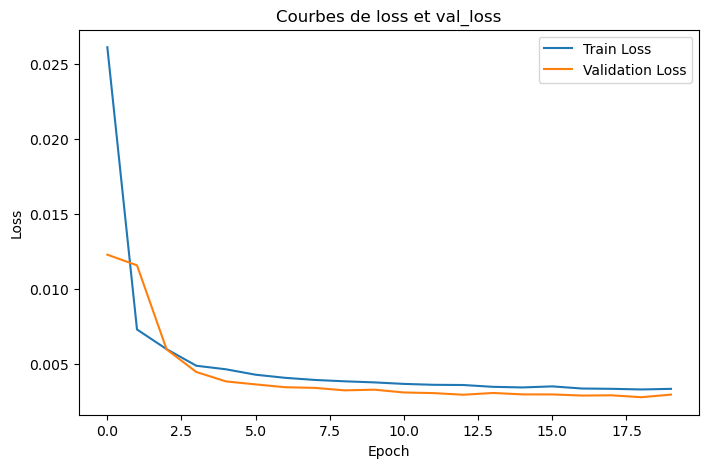

In [ ]:
## afficher la coube de l'evolution de la fonction de la perte loss et celle de Val_loss:

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Courbes de loss et val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


#####

In [ ]:
##faire les prediction avec X_test:
X_pred= model.predict(X_test)
## On calcul l'erreur de recontruction de chaque image de test:
reconstruction_error = np.mean(np.square(X_test - X_pred),axis=(1, 2, 3) )


# Seuil : 95ème percentile des images normales
threshold = np.percentile(reconstruction_error[y_test==0], 95)
## le seuil doit représenter le comportement normal du modèle, pas celui des anomalies.
print("Seuil de détection:", threshold)

# on applique le seuil au données des erreurs de construction:
y_pred = (reconstruction_error > threshold).astype(int)


54/54 ━━━━━━━━━━━━━━━━━━━━ 7s 117ms/step
Seuil de détection: 0.015232052


##### Évaluer la performance:

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print(f"Accuracy : {accuracy_score(y_test, y_pred):.2f}")
print(f"Precision: {precision_score(y_test, y_pred):.2f}")
print(f"Recall: {recall_score(y_test, y_pred): .2f}")
print(f"F1-score: {f1_score(y_test, y_pred):.2f}")
print(f"Confusion Matrix:\n {confusion_matrix(y_test, y_pred)}")

Accuracy : 0.29
Precision: 0.67
Recall:  0.04
F1-score: 0.07
Confusion Matrix:
 [[ 443   24]
 [1209   49]]


## classification supervisé de machine learning avec modele SVM pour l'ensemble des objets du dataset:

Dans ce cas nous allons créer des données train et test avec label.
bien reflichir pour voir comment faire les preprocessing afin d'avoir des données d'entrées prete

In [ ]:
## Fonction qui permet de faire les preprocessing necessaires pour l'ensemble des données du dataset:

def preprocessing_all (path):

    """ Fonction qui permet de faire les preprocessing basique pour lancer un modele de reseau de neuronne
      les argument:
            path: le chemin de l'emplacement des données
            color_mode = 'rgb': convertir toute les image en RGB même les images initialement en gris
                         afin de ne pas perdre l'information de la couleurs.

            Normalise: on normalise les images en remplacant tout les pixels avec des valeurs de 0 à 1
              """

    ## stocker les images prétraité:
    img_prp= []
    ##lire tout les images:
    img_paths = glob(os.path.join(path, "**", "*.*"), recursive=True)

    ## afficher le nombre d'image trouver par categorie:
    print(f"Nombre d'images trouvées dans {path} : {len(img_paths)}")

    for file_path in img_paths:

        ## Lire et modifier l'image la couleur de gray en RGB:
        img = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue


        ##redimentionnement des taille:
        img=cv2.resize(img, (256,256) )


        ##Normalisation:
        img=img.astype('float32')/255.



        ##ajouter le resultats dans la liste :
        img_prp.append(img)



    ##convertir la liste en tableau numpy:
    X = np.array(img_prp)


    return X




In [ ]:
##Appliquer les preprocessing pour l'ensemble des données de train/ good:

## pour cela nous allons utiliser la methode glob pour lire les fichier de train de l'ensemble des pieces :

path= r"/content/drive/MyDrive/Fomation_Data_Scientist/Projet_Detection_Anomalies/mvtec_anomaly_detection/*/train/good"
train_path= glob(path)

X_train_good= []
y_train_good=[]
for category_path in train_path:
    X_cate= preprocessing_all(category_path)
    y_anom = np.zeros(len(X_cate), dtype=np.int64)
    X_train_good.append(X_cate)
    y_train_good.append(y_anom)

X_train_good= np.concatenate(X_train_good, axis=0)
y_train_good= np.concatenate(y_train_good, axis=0)
print("X_train_good:", X_train_good.shape)
print("y_train_good:", y_train_good.shape, "labels:", np.unique(y_train_good))

Nombre d'images trouvées dans /content/drive/MyDrive/Fomation_Data_Scientist/Projet_Detection_Anomalies/mvtec_anomaly_detection/cable/train/good : 224
Nombre d'images trouvées dans /content/drive/MyDrive/Fomation_Data_Scientist/Projet_Detection_Anomalies/mvtec_anomaly_detection/hazelnut/train/good : 391
Nombre d'images trouvées dans /content/drive/MyDrive/Fomation_Data_Scientist/Projet_Detection_Anomalies/mvtec_anomaly_detection/capsule/train/good : 219
Nombre d'images trouvées dans /content/drive/MyDrive/Fomation_Data_Scientist/Projet_Detection_Anomalies/mvtec_anomaly_detection/leather/train/good : 245
Nombre d'images trouvées dans /content/drive/MyDrive/Fomation_Data_Scientist/Projet_Detection_Anomalies/mvtec_anomaly_detection/carpet/train/good : 280
Nombre d'images trouvées dans /content/drive/MyDrive/Fomation_Data_Scientist/Projet_Detection_Anomalies/mvtec_anomaly_detection/grid/train/good : 264
Nombre d'images trouvées dans /content/drive/MyDrive/Fomation_Data_Scientist/Projet_Det

##### Données test:

In [ ]:
## liste pour stocker X_test et y_test
X_test= []
y_test= []


## chemin du dataset:
path= r"C:/Users/hanou/OneDrive/Formation_DS/Projet/mvtec_anomaly_detection"

## création du chemin pour chaque categorie du dataset MVTec
categories= glob(path+ "/*")

##faire une boucle pour créer
for cat in categories:
    test_path = cat + "/test"
    if not os.path.exists(test_path): ##verifier si une categorie n'a pas de dossier
        continue

    # GOOD → label 0
    good_path = test_path + "/good"
    if os.path.exists(good_path):
        X_good = preprocessing_all(good_path)  ##appliquer les preprocessing au données de test/good
        y_good = np.zeros(len(X_good), dtype=np.int64)  ## création d'un label 0 pour les données good et les stocker dans y_test
        X_test.append(X_good)
        y_test.append(y_good)

    # ANOMALIES → label 1
    for anomaly in os.listdir(test_path):
        if anomaly == "good":  ##on ignore le dossier good car on l'avait déja traité et stocker.
            continue

        ## création d'un nouveau path pour l'ensemble des anomalie de chauq piéces
        anomaly_path = test_path + "/" + anomaly
        if os.path.isdir(anomaly_path):  ## on verifier que c'est bien un dossier.
            X_anom = preprocessing_all(anomaly_path)  ## on applique les preprocessing instancier dans la focntion preprocessing_all
            y_anom = np.ones(len(X_anom), dtype=np.int64)  ## on ajoute un label au image avec anomalie de valeur 1
            X_test.append(X_anom)
            y_test.append(y_anom)

##faire la concaténation pour créer X_test et y_test final
X_test = np.concatenate(X_test, axis=0)
y_test = np.concatenate(y_test, axis=0)

print(X_test.shape, y_test.shape)


Nombre d'images trouvées dans C:/Users/hanou/OneDrive/Formation_DS/Projet/mvtec_anomaly_detection\bottle/test/good : 20
Nombre d'images trouvées dans C:/Users/hanou/OneDrive/Formation_DS/Projet/mvtec_anomaly_detection\bottle/test/broken_large : 20
Nombre d'images trouvées dans C:/Users/hanou/OneDrive/Formation_DS/Projet/mvtec_anomaly_detection\bottle/test/broken_small : 22
Nombre d'images trouvées dans C:/Users/hanou/OneDrive/Formation_DS/Projet/mvtec_anomaly_detection\bottle/test/contamination : 21
Nombre d'images trouvées dans C:/Users/hanou/OneDrive/Formation_DS/Projet/mvtec_anomaly_detection\cable/test/good : 58
Nombre d'images trouvées dans C:/Users/hanou/OneDrive/Formation_DS/Projet/mvtec_anomaly_detection\cable/test/bent_wire : 13
Nombre d'images trouvées dans C:/Users/hanou/OneDrive/Formation_DS/Projet/mvtec_anomaly_detection\cable/test/cable_swap : 12
Nombre d'images trouvées dans C:/Users/hanou/OneDrive/Formation_DS/Projet/mvtec_anomaly_detection\cable/test/combined : 11
Nomb

In [ ]:
## pour sauvegarder les dossiers train et test:
joblib.dump((X_train_good, y_train_good, X_test, y_test),"dataset_splits(64_64).pkl")


['dataset_splits(64_64).pkl']

In [ ]:
## pour lire les dossiers:
X_train_good, y_train_good, X_test, y_test = joblib.load("dataset_splits(64_64).pkl")


In [ ]:
##fusion des données test avec train pour créer les dossier X et y:
X = np.concatenate([X_train_good, X_test], axis=0)
y = np.concatenate([y_train_good, y_test], axis=0)

print(X.shape, y.shape)


(5354, 64, 64) (5354,)


In [ ]:
## pour sauvegarder les dossiers X et y:
joblib.dump((X, y),"X_y(64_64).pkl")

['X_y(64_64).pkl']

#### entrainnement du modele sans augmentation de la données :

In [ ]:
from sklearn.model_selection import train_test_split
## Applatir les données de X:
##X_flat=X.flatten()
X_flat = X.reshape(X.shape[0], -1)
##spliter en données d'entrainnement et de test on laissant 20% pour les données test:

X_train, X_test, y_train, y_test= train_test_split(X_flat, y, test_size=0.2, random_state=42)

In [ ]:

svm = SVC(gamma='scale')

svm.fit(X_train, y_train)

y_pred= svm.predict(X_test)
print(f"le score obtenu sur les données test est: {svm.score(X_test, y_test)}")

print(pd.crosstab(y_test, y_pred, rownames =['calsse réelle'], colnames=['classe predicte']))

# le rapport d'évaluation du modèle sur l'échantillon de test

print(classification_report_imbalanced(y_test, y_pred))

le score obtenu sur les données test est: 0.7852474323062558
classe predicte    0  1
calsse réelle          
0                839  0
1                230  2
                   pre       rec       spe        f1       geo       iba       sup

          0       0.78      1.00      0.01      0.88      0.09      0.01       839
          1       1.00      0.01      1.00      0.02      0.09      0.01       232

avg / total       0.83      0.79      0.22      0.69      0.09      0.01      1071



In [ ]:
# Ajout du parametre class_weight='balanced' pour gerer les desiquilibre
svm = SVC(gamma='scale',C=0.1,kernel='rbf',class_weight='balanced')

svm.fit(X_train, y_train)

y_pred= svm.predict(X_test)
print(f"le score obtenu sur les données test est: {svm.score(X_test, y_test)}")

print(pd.crosstab(y_test, y_pred, rownames =['calsse réelle'], colnames=['classe predicte']))

# le rapport d'évaluation du modèle sur l'échantillon de test

print(classification_report_imbalanced(y_test, y_pred))

le score obtenu sur les données test est: 0.6293183940242764
classe predicte    0    1
calsse réelle            
0                586  253
1                144   88
                   pre       rec       spe        f1       geo       iba       sup

          0       0.80      0.70      0.38      0.75      0.51      0.27       839
          1       0.26      0.38      0.70      0.31      0.51      0.26       232

avg / total       0.68      0.63      0.45      0.65      0.51      0.27      1071



| **Métrique** | **Nom complet**            | **Formule (simplifiée)** | **Ce que ça mesure**                | **Ce que ça veut dire (en clair)**               | **Valeur idéale** | **Interprétation en anomalies**              |
| ------------ | -------------------------- | ------------------------ | ----------------------------------- | ------------------------------------------------ | ----------------- | -------------------------------------------- |
| **pre**      | Precision                  | TP / (TP + FP)           | Fiabilité des prédictions positives | Quand le modèle dit “anomalie”, a-t-il raison ?  | **Proche de 1**   | Réduit les fausses alertes                   |
| **rec**      | Recall (Sensibilité)       | TP / (TP + FN)           | Capacité à détecter une classe      | Combien d’anomalies sont détectées ?             | **Proche de 1**   | **Critique : éviter les anomalies manquées** |
| **spe**      | Specificity                | TN / (TN + FP)           | Capacité à reconnaître les négatifs | Le modèle identifie-t-il bien les normales ?     | **Proche de 1**   | Limite le bruit / fausses alertes            |
| **f1**       | F1-score                   | 2·(pre·rec)/(pre+rec)    | Équilibre précision / rappel        | Qualité globale par classe                       | **Proche de 1**   | Compromis détection / erreurs                |
| **geo**      | G-Mean                     | √(rec · spe)             | Équilibre entre classes             | Le modèle est-il biaisé vers une classe ?        | **Proche de 1**   | Indicateur clé en anomalies                  |
| **iba**      | Index of Balanced Accuracy | f(rec, spe)              | Performance équilibrée pénalisée    | Le modèle est-il fiable malgré le déséquilibre ? | **Proche de 1**   | Robustesse globale                           |
| **sup**      | Support                    | —                        | Nb réel d’échantillons              | Combien d’exemples réels dans cette classe ?     | —                 | Indique le déséquilibre                      |


Les résultats montrent une amélioration notable de la capacité du modèle à détecter la classe minoritaire. Le rappel de la classe anomalie atteint 38 %, contre une valeur quasi nulle précédemment, traduisant une réduction du biais vers la classe majoritaire. Cette amélioration s’accompagne toutefois d’une augmentation du taux de faux positifs, comme en témoigne une précision de 26 % pour la classe anomalie. Le G-Mean de 0.51 indique un compromis plus équilibré entre la détection des classes normales et anormales, bien que des marges de progression subsistent.

#### Entrainnement du modele avec une méthode d'undersampling:

In [ ]:
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.combine import SMOTETomek
from imblearn.under_sampling import RandomUnderSampler,  ClusterCentroids

In [ ]:
y.shape

(5354,)

In [ ]:
from collections import Counter
print(Counter(y))

##onremarque que la classe 0 (images sans anomalies) est majoritaire et represente 3.5 fois la classe 1.
##on va essayer dans un npremiere temps la diminution de la classe 0 avec le modele RandomUnderSampling()

Counter({np.int64(0): 4096, np.int64(1): 1258})


In [ ]:
rUs = RandomUnderSampler()

X_ru, y_ru = rUs.fit_resample(X_train, y_train)

print('Classes échantillon undersampled :', dict(pd.Series(y_ru).value_counts()))

Classes échantillon undersampled : {0: np.int64(1026), 1: np.int64(1026)}


In [ ]:
# Insérez votre code ici
svm = SVC(gamma='scale',C=0.1,kernel='rbf',class_weight='balanced')

svm.fit(X_ru, y_ru)

y_pred= svm.predict(X_test)
print(f"le score obtenu sur les données test est: {svm.score(X_test, y_test)}")

print(pd.crosstab(y_test, y_pred, rownames =['calsse réelle'], colnames=['classe predicte']))

# le rapport d'évaluation du modèle sur l'échantillon de test

print(classification_report_imbalanced(y_test, y_pred))

le score obtenu sur les données test est: 0.5994397759103641
classe predicte    0    1
calsse réelle            
0                546  293
1                136   96
                   pre       rec       spe        f1       geo       iba       sup

          0       0.80      0.65      0.41      0.72      0.52      0.28       839
          1       0.25      0.41      0.65      0.31      0.52      0.26       232

avg / total       0.68      0.60      0.47      0.63      0.52      0.27      1071



#### Entrainnement des modele avec l'augmentation des données train:

In [ ]:
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:

def augment_normal(img):
    """Augmentation légère pour images normales (gray, shape HxW)."""
    out = img.copy()

    # 1) rotation légère
    if np.random.rand() < 0.5:
        angle = np.random.uniform(-7, 7)
        h, w = out.shape
        M = cv2.getRotationMatrix2D((w/2, h/2), angle, 1.0)
        out = cv2.warpAffine(out, M, (w, h), borderMode=cv2.BORDER_REFLECT)

    # 2) translation légère
    if np.random.rand() < 0.5:
        h, w = out.shape
        tx = np.random.uniform(-0.05*w, 0.05*w)
        ty = np.random.uniform(-0.05*h, 0.05*h)
        M = np.float32([[1, 0, tx], [0, 1, ty]])
        out = cv2.warpAffine(out, M, (w, h), borderMode=cv2.BORDER_REFLECT)

    # 3) bruit gaussien léger
    if np.random.rand() < 0.4:
        noise = np.random.normal(0, 0.02, out.shape).astype(np.float32)
        out = np.clip(out + noise, 0, 1)

    # 4) variation de luminosité légère
    if np.random.rand() < 0.4:
        factor = np.random.uniform(0.9, 1.1)
        out = np.clip(out * factor, 0, 1)

    return out.astype(np.float32)


def augment_dataset(X_train, y_train, k_normal=1):
    X_new, y_new = [], []

    for img, label in zip(X_train, y_train):
        X_new.append(img)
        y_new.append(label)

        for _ in range(k_normal):
            X_new.append(augment_normal(img))
            y_new.append(label)  # garde automatiquement 0 ou 1

    return np.array(X_new, np.float32), np.array(y_new, np.int64)



X_train_aug, y_train_aug = augment_dataset(X_train, y_train)
print(X_train.shape, "->", X_train_aug.shape)
print("Classes:", np.unique(y_train_aug, return_counts=True))

In [ ]:
print(Counter(y_train_aug))

Counter({np.int64(0): 6514, np.int64(1): 2052})


In [ ]:
# flatten
Xtr = X_train_aug.reshape(X_train_aug.shape[0], -1)
Xte = X_test.reshape(X_test.shape[0], -1)

# scaler (fit train, transform test)
scaler = StandardScaler()
Xtr = scaler.fit_transform(Xtr)
Xte = scaler.transform(Xte)


In [ ]:
svm = SVC(gamma="scale",class_weight="balanced")
svm.fit(Xtr, y_train_aug)

y_pred= svm.predict(Xte)
print(f"le score obtenu sur les données test est: {svm.score(Xte, y_test)}")

print(pd.crosstab(y_test, y_pred, rownames =['calsse réelle'], colnames=['classe predicte']))

# le rapport d'évaluation du modèle sur l'échantillon de test

print(classification_report_imbalanced(y_test, y_pred))

le score obtenu sur les données test est: 0.6760037348272643
classe predicte    0    1
calsse réelle            
0                588  251
1                 96  136
                   pre       rec       spe        f1       geo       iba       sup

          0       0.86      0.70      0.59      0.77      0.64      0.42       839
          1       0.35      0.59      0.70      0.44      0.64      0.41       232

avg / total       0.75      0.68      0.61      0.70      0.64      0.41      1071



###### Interprétation des résultats du modèle

Le modèle obtient une accuracy de 67,6 % sur les données de test. Ce score indique une performance globale correcte, mais il doit être analysé avec prudence compte tenu du déséquilibre des classes et de l’objectif de détection des anomalies.

La matrice de confusion montre que le modèle identifie correctement 588 images normales et 136 images anormales. Toutefois, 251 images normales sont incorrectement classées comme anomalies (faux positifs), tandis que 96 anomalies réelles ne sont pas détectées (faux négatifs). Cela traduit un compromis entre la capacité à détecter les anomalies et le risque de générer des fausses alertes.

Pour la classe normale (0), le modèle présente une précision élevée (0,86), ce qui signifie que lorsqu’il prédit une image comme normale, cette prédiction est majoritairement correcte. En revanche, le rappel de 0,70 indique que 30 % des images normales sont mal classées comme anomalies, ce qui explique le nombre important de faux positifs observés.

Concernant la classe anormale (1), le rappel de 0,59 montre que le modèle détecte un peu plus de la moitié des anomalies réelles, ce qui est un résultat raisonnable dans un contexte de détection d’anomalies. Cependant, la précision relativement faible (0,35) indique qu’une part importante des images prédites comme anomalies sont en réalité normales, confirmant une tendance à la sur-détection.

Le F1-score de la classe anormale (0,44) reflète ce compromis entre rappel et précision. Les métriques globales, notamment la moyenne géométrique (G-mean = 0,64) et l’IBA (0,41), montrent que le modèle conserve un équilibre acceptable entre la détection des deux classes, sans toutefois exceller sur la classe minoritaire.

#### Entrainnement des modele avec l'augmentation des données avec la création d'anomalie artificiel avec les données des données train

In [ ]:
def make_artificial_anomaly(img):
    """Crée une anomalie artificielle sur une image normale (gray, HxW)."""
    out = img.copy()
    h, w = out.shape

    mode = np.random.choice(["occlusion", "scratch", "local_noise", "local_blur"]) ##choix aléatoire du type d'anomalie

    if mode == "occlusion": ##cacher une zone
        ph = np.random.randint(h//12, h//5)
        pw = np.random.randint(w//12, w//5)
        y0 = np.random.randint(0, h - ph)
        x0 = np.random.randint(0, w - pw)
        val = np.random.choice([0.0, 1.0])  # patch noir ou blanc
        out[y0:y0+ph, x0:x0+pw] = val

    elif mode == "scratch": ##ajouter une rayure
        # ligne fine aléatoire
        x1, y1 = np.random.randint(0, w), np.random.randint(0, h)
        x2, y2 = np.random.randint(0, w), np.random.randint(0, h)
        thickness = np.random.randint(1, 3)
        color = float(np.random.uniform(0.0, 1.0))
        out = out.copy()
        cv2.line(out, (x1, y1), (x2, y2), color, thickness)

    elif mode == "local_noise": ##ajouter du bruit
        ph = np.random.randint(h//10, h//4)
        pw = np.random.randint(w//10, w//4)
        y0 = np.random.randint(0, h - ph)
        x0 = np.random.randint(0, w - pw)
        noise = np.random.normal(0, 0.12, (ph, pw)).astype(np.float32)
        out[y0:y0+ph, x0:x0+pw] = np.clip(out[y0:y0+ph, x0:x0+pw] + noise, 0, 1)

    elif mode == "local_blur": ##ajouter du flou
        ph = np.random.randint(h//10, h//4)
        pw = np.random.randint(w//10, w//4)
        y0 = np.random.randint(0, h - ph)
        x0 = np.random.randint(0, w - pw)
        patch = out[y0:y0+ph, x0:x0+pw]
        patch = cv2.GaussianBlur(patch, (5, 5), 0)
        out[y0:y0+ph, x0:x0+pw] = patch

    return np.clip(out, 0, 1).astype(np.float32)


In [ ]:
def augment_dataset_anomaly_artificiel(X_train, y_train, m_anom=1):
    X_new, y_new = [], []

    for img, label in zip(X_train, y_train):
        # garder l'original
        X_new.append(img)
        y_new.append(label)

        # créer des anomalies artificielles depuis les images normales
        if label == 0:
            for _ in range(m_anom):
                X_new.append(make_artificial_anomaly(img))
                y_new.append(1)  # 0 -> 1

    return np.array(X_new, np.float32), np.array(y_new, np.int64)


In [ ]:
X_train_aug_ar, y_train_aug_ar = augment_dataset_anomaly_artificiel(X_train, y_train, m_anom=3)
print(X_train.shape, "->", X_train_aug_ar.shape)
print("Classes:", np.unique(y_train_aug_ar, return_counts=True))


(4283, 64, 64) -> (14054, 64, 64)
Classes: (array([0, 1]), array([ 3257, 10797]))


In [ ]:
print(Counter(y_train_aug_ar))

Counter({np.int64(1): 10797, np.int64(0): 3257})


In [ ]:
# flatten
X_tr_ar = X_train_aug_ar.reshape(X_train_aug_ar.shape[0], -1)
X_test_ar = X_test.reshape(X_test.shape[0], -1)

# scaler (fit train, transform test)
scaler = StandardScaler()
X_tr_ar = scaler.fit_transform(X_tr_ar)
X_test_ar = scaler.transform(X_test_ar)


In [ ]:
svm = SVC(gamma="scale",class_weight="balanced")
svm.fit(X_tr_ar, y_train_aug_ar)

y_pred= svm.predict(X_test_ar)
print(f"le score obtenu sur les données test est: {svm.score(X_test_ar, y_test)}")

print(pd.crosstab(y_test, y_pred, rownames =['calsse réelle'], colnames=['classe predicte']))

# le rapport d'évaluation du modèle sur l'échantillon de test

print(classification_report_imbalanced(y_test, y_pred))

le score obtenu sur les données test est: 0.6918767507002801
classe predicte    0    1
calsse réelle            
0                671  168
1                162   70
                   pre       rec       spe        f1       geo       iba       sup

          0       0.81      0.80      0.30      0.80      0.49      0.25       839
          1       0.29      0.30      0.80      0.30      0.49      0.23       232

avg / total       0.69      0.69      0.41      0.69      0.49      0.25      1071



###### Interprétation des résultats du modèle

Le modèle atteint une accuracy de 69,2 %, indiquant une performance globale correcte. Il identifie bien la classe normale (0), avec un rappel de 0,80, ce qui signifie que la majorité des images normales sont correctement reconnues. En revanche, la classe anormale (1) est moins bien détectée, avec un rappel de 0,30, montrant que près de 70 % des anomalies ne sont pas identifiées. La précision faible (0,29) pour cette classe indique également une proportion importante de fausses alertes parmi les prédictions d’anomalies. Globalement, le modèle privilégie la reconnaissance du normal au détriment de la détection des anomalies, ce qui est cohérent avec un jeu de données déséquilibré.

#### TEST: Augementation de la classe 0 pour attendre 20% que la classe1 à partir des resultats de l'augmentation artificielles des anomalies

In [ ]:

def oversample_class0_ratio(X_train, y_train, ratio=1.2, seed=42):
    """
    Augmente la classe 0 pour atteindre ratio * n1.
    ratio=1.2 -> classe0 = 120% de classe1
    """
    rng = np.random.default_rng(seed)

    X0 = X_train[y_train == 0]
    X1 = X_train[y_train == 1]

    n0, n1 = len(X0), len(X1)
    if n0 == 0 or n1 == 0:
        raise ValueError("Il faut au moins un échantillon dans chaque classe (0 et 1).")

    target0 = int(np.ceil(ratio * n1))
    need = target0 - n0

    print(f"n0 actuel={n0}, n1={n1}")
    print(f"cible n0={target0} (ratio={ratio}), à ajouter={need}")

    if need <= 0:
        print("La classe 0 est déjà >= cible. Rien à faire.")
        return X_train.astype(np.float32), y_train.astype(np.int64)

    X_new = [*X_train]
    y_new = [*y_train]

    for _ in range(need):
        img = X0[rng.integers(0, n0)]
        img_aug = augment_normal(img)  # augmentation "neutre" -> label reste 0
        X_new.append(img_aug)
        y_new.append(0)

    X_new = np.array(X_new, dtype=np.float32)
    y_new = np.array(y_new, dtype=np.int64)

    # shuffle
    idx = rng.permutation(len(y_new))
    return X_new[idx], y_new[idx]


In [ ]:
X_train_new, y_train_new = oversample_class0_ratio(X_train_aug_ar, y_train_aug_ar, ratio=1.2)

print("Nouvelles classes:", np.unique(y_train_new, return_counts=True))


n0 actuel=3257, n1=10797
cible n0=12957 (ratio=1.2), à ajouter=9700
Nouvelles classes: (array([0, 1]), array([12957, 10797]))


In [ ]:
# flatten
X_tr_ag_0 = X_train_new.reshape(X_train_new.shape[0], -1)
X_test_ag_0 = X_test.reshape(X_test.shape[0], -1)

# scaler (fit train, transform test)
scaler = StandardScaler()
X_tr_ar = scaler.fit_transform(X_tr_ag_0)
X_test_ar = scaler.transform(X_test_ag_0)

In [ ]:
svm = SVC(gamma="scale")
svm.fit(X_tr_ag_0, y_train_new)

y_pred= svm.predict(X_test_ag_0)
print(f"le score obtenu sur les données test est: {svm.score(X_test_ag_0, y_test)}")

print(pd.crosstab(y_test, y_pred, rownames =['calsse réelle'], colnames=['classe predicte']))

# le rapport d'évaluation du modèle sur l'échantillon de test

print(classification_report_imbalanced(y_test, y_pred))

le score obtenu sur les données test est: 0.453781512605042
classe predicte    0    1
calsse réelle            
0                335  504
1                 81  151
                   pre       rec       spe        f1       geo       iba       sup

          0       0.81      0.40      0.65      0.53      0.51      0.25       839
          1       0.23      0.65      0.40      0.34      0.51      0.27       232

avg / total       0.68      0.45      0.60      0.49      0.51      0.26      1071



## classification supervisé de machine learning avec modele MLPClassifier pour Chaque objet du dataset et en integrant la segmentation et l'extraction du features et aussi l'augmentation des image avec anomalies:

Dans cette partie nous avons choisis de faire une classification supervisée en machine learning avec le modele MLPClassifier  pour chaque objet en integrant de la segmentation.

#### **`1. Modele pour cable:`**

Dans cette partie, nous alons faire un modele pour la categorie cable afin de voir si notre approche permet d'obtenir un modele perfermant qui arrive à classer la classe des anomalies avec une bonne precision et un bon rappel aussi.

###### **`Segmentation:`**

Pour chaque catégorie du jeu de données MVTec, une analyse visuelle a permis d’identifier la nature dominante des défauts. Les défauts chromatiques ont été traités par une segmentation basée sur la couleur, tandis que les défauts structurels ont été traités par une segmentation basée sur les contours. Lorsque les défauts sont internes ou purement texturels, aucune segmentation n’a été appliquée.

| Catégorie MVTec | Type de catégorie | Type dominant de défaut         | Segmentation recommandée |
| --------------- | ----------------- | ------------------------------- | ------------------------ |
| **carpet**      | Texture           | Texture / couleur diffuse       | **Couleur**              |
| **grid**        | Texture           | Structure (lignes cassées)      | **Contours**             |
| **leather**     | Texture           | Couleur / texture               | **Couleur**              |
| **tile**        | Texture           | Couleur / motif                 | **Couleur**              |
| **wood**        | Texture           | Couleur / texture               | **Couleur**              |
| **bottle**      | Objet             | Texture interne / contamination | **Aucune**               |
| **cable**       | Objet             | Structure / coupure             | **Contours**             |
| **capsule**     | Objet             | Couleur / texture               | **Couleur**              |
| **hazelnut**    | Objet             | Couleur (zones brunies)         | **Couleur**              |
| **metal_nut**   | Objet             | Forme / géométrie               | **Contours**             |
| **pill**        | Objet             | Couleur / surface               | **Couleur**              |
| **screw**       | Objet             | Forme / orientation             | **Contours**             |
| **toothbrush**  | Objet             | Forme / structure               | **Contours**             |
| **transistor**  | Objet             | Structure / composants          | **Contours**             |
| **zipper**      | Objet             | Structure (dents manquantes)    | **Contours**             |


In [2]:
def segment_color_simple(img):
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    h, s, v = cv2.split(hsv)

    mask = (s > 30).astype("uint8") * 255
    return cv2.bitwise_and(img, img, mask=mask)


In [3]:
def segment_contour_simple(img):
    # Si l'image est déjà en niveaux de gris
    if img.ndim == 2:
        gray = img
    else:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    edges = cv2.Canny(gray, 50, 150)

    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return img

    c = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(c)

    return img[y:y+h, x:x+w]

In [4]:
SEGMENTATION_BY_CATEGORY = {
    "grid": "contour",
    "cable": "contour",
    "screw": "contour",
    "zipper": "contour",
    "metal_nut": "contour",

    "wood": "color",
    "leather": "color",
    "tile": "color",
    "carpet": "color",
    "pill": "color",
    "hazelnut": "color",
    "capsule": "color",

    "bottle": "none",
}


In [5]:
##choisir la segmentation à appliquer

def apply_segmentation(img, category):
    mode = SEGMENTATION_BY_CATEGORY.get(category, "none")

    if mode == "contour":
        return segment_contour_simple(img)

    elif mode == "color":
        return segment_color_simple(img)

    else:  # "none"
        return img


**Justification des choix de segmentation par categorie:**

| Catégorie      | Type    | Segmentation choisie | Pourquoi ce choix est pertinent                                                                                                                                                                |
| -------------- | ------- | -------------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **carpet**     | Texture | Couleur              | Les défauts apparaissent comme des variations chromatiques et de texture réparties sur la surface. La segmentation couleur permet d’isoler les zones anormales et de réduire le bruit du fond. |
| **grid**       | Texture | Contours             | Les défauts se traduisent par des ruptures de lignes et des discontinuités structurelles. La segmentation par contours met en évidence ces anomalies géométriques.                             |
| **leather**    | Texture | Couleur              | Les défauts correspondent principalement à des décolorations et des irrégularités de surface visibles par la couleur.                                                                          |
| **tile**       | Texture | Couleur              | Les anomalies modifient les motifs et la teinte des carreaux. La segmentation couleur permet de détecter ces différences chromatiques.                                                         |
| **wood**       | Texture | Couleur              | Les défauts (taches, brûlures) sont principalement de nature chromatique et se distinguent par la couleur.                                                                                     |
| **bottle**     | Objet   | Aucune               | L’objet est centré sur fond uniforme et les défauts sont internes. Une segmentation pourrait supprimer des informations utiles.                                                                |
| **cable**      | Objet   | Contours             | Les défauts affectent la structure du câble (coupures, déformations). La segmentation par contours permet d’isoler la forme.                                                                   |
| **capsule**    | Objet   | Couleur              | Les défauts se manifestent par des variations de couleur et de texture sur la surface.                                                                                                         |
| **hazelnut**   | Objet   | Couleur              | Les anomalies sont visibles sous forme de zones brunies ou décolorées, donc chromatiques.                                                                                                      |
| **metal_nut**  | Objet   | Contours             | Les défauts modifient la géométrie et les arêtes de l’objet métallique. Les contours sont discriminants.                                                                                       |
| **pill**       | Objet   | Couleur              | Les anomalies correspondent à des différences de teinte et d’aspect de surface.                                                                                                                |
| **screw**      | Objet   | Contours             | Les défauts entraînent des déformations de la vis, visibles au niveau de la forme et des bords.                                                                                                |
| **toothbrush** | Objet   | Contours             | Les anomalies affectent la structure et l’alignement de l’objet.                                                                                                                               |
| **transistor** | Objet   | Contours             | Les défauts sont liés à la disposition et à la forme des composants.                                                                                                                           |
| **zipper**     | Objet   | Contours             | Les anomalies se manifestent par des dents manquantes ou mal alignées, donc structurelles.                                                                                                     |


###### **`Appliquer une extraction de feature :`**

In [6]:
def extract_color_features(img, bins=16):
    """
    Histogrammes couleur simples (HSV).
    Retourne un vecteur 1D normalisé.
    """
    # Si image en gris → pas de couleur
    if img.ndim == 2:
        return np.zeros(bins * 2, dtype=np.float32)

    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    hist_h = cv2.calcHist([hsv], [0], None, [bins], [0, 180])
    hist_s = cv2.calcHist([hsv], [1], None, [bins], [0, 256])

    hist = np.concatenate([hist_h, hist_s]).flatten()
    hist = hist / (hist.sum() + 1e-8)

    return hist.astype(np.float32)


In [7]:
def extract_lbp_features(img):
    """
    LBP simple (8 voisins) + histogramme.
    """
    if img.ndim == 3:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        gray = img

    gray = gray.astype(np.uint8)
    h, w = gray.shape

    lbp = np.zeros((h, w), dtype=np.uint8)

    for y in range(1, h - 1):
        for x in range(1, w - 1):
            center = gray[y, x]
            code = 0
            code |= (gray[y-1, x-1] >= center) << 7
            code |= (gray[y-1, x  ] >= center) << 6
            code |= (gray[y-1, x+1] >= center) << 5
            code |= (gray[y,   x+1] >= center) << 4
            code |= (gray[y+1, x+1] >= center) << 3
            code |= (gray[y+1, x  ] >= center) << 2
            code |= (gray[y+1, x-1] >= center) << 1
            code |= (gray[y,   x-1] >= center) << 0
            lbp[y, x] = code

    hist, _ = np.histogram(lbp.ravel(), bins=256, range=(0, 256))
    hist = hist.astype(np.float32)
    hist = hist / (hist.sum() + 1e-8)

    return hist


In [8]:
def extract_hog_features(img):
    """
    HOG simple avec OpenCV.
    """
    if img.ndim == 3:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        gray = img

    gray = cv2.resize(gray, (128, 128))

    hog = cv2.HOGDescriptor(
        _winSize=(128, 128),
        _blockSize=(16, 16),
        _blockStride=(8, 8),
        _cellSize=(8, 8),
        _nbins=9
    )

    features = hog.compute(gray)
    return features.flatten().astype(np.float32)


In [9]:
def extract_features(img, category):
    features = []

    if category in ["wood", "leather", "tile", "carpet", "pill", "hazelnut", "capsule"]:
        features.append(extract_color_features(img))
        features.append(extract_lbp_features(img))

    elif category in ["grid", "cable", "screw", "zipper", "metal_nut",
                      "toothbrush", "transistor"]:
        features.append(extract_hog_features(img))

    elif category == "bottle":
        features.append(extract_lbp_features(img))
        features.append(extract_hog_features(img))

    else:
        features.append(extract_lbp_features(img))

    return np.concatenate(features)


Dans le tableau ci-dessous nous avons detaillé et justifier les choix des extraction de feature utilisé pour chaque categorie:

| Catégorie      | Type (Texture / Objet) | Type dominant de défaut         | Segmentation choisie | Features recommandées | Justification                                               |
| -------------- | ---------------------- | ------------------------------- | -------------------- | --------------------- | ----------------------------------------------------------- |
| **carpet**     | Texture                | Texture / couleur diffuse       | Couleur              | Couleur + LBP         | Défauts visibles par variations chromatiques et texturelles |
| **grid**       | Texture                | Structure (lignes cassées)      | Contours             | HOG                   | Les anomalies sont des ruptures géométriques                |
| **leather**    | Texture                | Couleur / texture               | Couleur              | Couleur + LBP         | Défauts visibles par décoloration et texture                |
| **tile**       | Texture                | Motif / couleur                 | Couleur              | Couleur + LBP         | Changements de motif et de teinte                           |
| **wood**       | Texture                | Couleur / texture               | Couleur              | Couleur + LBP         | Taches et brûlures chromatiques                             |
| **bottle**     | Objet                  | Texture interne / contamination | Aucune               | LBP + HOG             | Défauts internes détectables par texture                    |
| **cable**      | Objet                  | Structure / coupure             | Contours             | HOG                   | Défauts de forme et de continuité                           |
| **capsule**    | Objet                  | Couleur / texture               | Couleur              | Couleur + LBP         | Variations chromatiques de surface                          |
| **hazelnut**   | Objet                  | Couleur (zones brunies)         | Couleur              | Couleur + LBP         | Anomalies visibles par la teinte                            |
| **metal_nut**  | Objet                  | Géométrie / arêtes              | Contours             | HOG                   | Défauts affectant la forme                                  |
| **pill**       | Objet                  | Couleur / surface               | Couleur              | Couleur + LBP         | Défauts chromatiques et texturels                           |
| **screw**      | Objet                  | Forme / orientation             | Contours             | HOG                   | Déformations de la vis                                      |
| **toothbrush** | Objet                  | Structure                       | Contours             | HOG                   | Défauts géométriques                                        |
| **transistor** | Objet                  | Structure / composants          | Contours             | HOG                   | Disposition anormale des composants                         |
| **zipper**     | Objet                  | Structure (dents manquantes)    | Contours             | HOG                   | Ruptures dans la structure des dents                        |


###### **`Appliquer les preprocissing et création de X et y à partir des données de train et test :`**

In [10]:
## préprocessing: Création des dossiers X et y avec les données train et test melangé dans X et les labels dans y:
## Fonction qui permet de faire les preprocessing necessaires:

def Dataset_supervise (path, category):

    """ fonction qui permet de regrouper


              """

    ## stocker les images prétraité:
    img_prp= []
    ##lire tout les images:
    img_paths = glob(os.path.join(path, "**", "*.*"), recursive=True)

    ## afficher le nombre d'image trouver par categorie:
    print(f"Nombre d'images trouvées dans {category} : {len(img_paths)}")



    ## Lire les images sans les convertir en gris
    for file_path in img_paths:
      img = cv2.imread(file_path, cv2.IMREAD_UNCHANGED)
      if img is None:
        continue
      if img.ndim == 3 and img.shape[2] == 4:
        img = cv2.cvtColor(img, cv2.COLOR_BGRA2BGR)



      ##redimentionnement des taille:
      img=cv2.resize(img, (256,256))


      # SEGMENTATION: ajouter une condition pour lancer lensembel des categorie
      img = apply_segmentation(img, category)

      # remettre à taille fixe après segmentation
      img = cv2.resize(img, (256, 256))

      #EXTRACTION DE FEATURES
      feature = extract_features(img, category)


      ##ajouter le resultats dans la liste :
      img_prp.append(feature)



    ##convertir la liste en tableau numpy:
    X = np.array(img_prp)


    return X





In [11]:
##Appliquer les preprocessing pour l'ensemble des données de train/ good:

## pour cela nous allons utiliser la methode glob pour lire les fichier de train de l'ensemble des pieces :

path= r"/content/drive/MyDrive/Fomation_Data_Scientist/Projet_Detection_Anomalies/mvtec_anomaly_detection/grid/train/good"
train_path= glob(path)

X_train_grid= []
y_train_grid=[]
for category_path in train_path:
  category = os.path.basename(os.path.dirname(os.path.dirname(category_path)))
  X_cate= Dataset_supervise(category_path,category)
  y_anom = np.zeros(len(X_cate), dtype=np.int64)
  X_train_grid.append(X_cate)
  y_train_grid.append(y_anom)

X_train_grid= np.concatenate(X_train_grid, axis=0)
y_train_grid= np.concatenate(y_train_grid, axis=0)
print("X_train_good:", X_train_grid.shape)
print("y_train_good:", y_train_grid.shape, "labels:", np.unique(y_train_grid))

Nombre d'images trouvées dans grid : 264
X_train_good: (264, 8100)
y_train_good: (264,) labels: [0]


In [13]:
## liste pour stocker X_test et y_test
X_test_grid= []
y_test_grid= []


## chemin du dataset:
path= r"/content/drive/MyDrive/Fomation_Data_Scientist/Projet_Detection_Anomalies/mvtec_anomaly_detection"

## création du chemin pour chaque categorie du dataset MVTec
categories= glob(path+ "/grid")

##faire une boucle pour créer
for cat in categories:
    category = os.path.basename(cat)
    test_path = cat + "/test"
    if not os.path.exists(test_path): ##verifier si une categorie n'a pas de dossier
        continue

    # GOOD → label 0
    good_path = test_path + "/good"
    if os.path.exists(good_path):
        X_good = Dataset_supervise(good_path, category)  ##appliquer les preprocessing au données de test/good
        y_good = np.zeros(len(X_good), dtype=np.int64)  ## création d'un label 0 pour les données good et les stocker dans y_test
        X_test_grid.append(X_good)
        y_test_grid.append(y_good)

    # ANOMALIES → label 1
    for anomaly in os.listdir(test_path):
        if anomaly == "good":  ##on ignore le dossier good car on l'avait déja traité et stocker.
            continue

        ## création d'un nouveau path pour l'ensemble des anomalie de chauq piéces
        anomaly_path = test_path + "/" + anomaly
        if os.path.isdir(anomaly_path):  ## on verifier que c'est bien un dossier.
            X_anom = Dataset_supervise(anomaly_path, category)  ## on applique les preprocessing instancier dans la focntion preprocessing_all
            y_anom = np.ones(len(X_anom), dtype=np.int64)  ## on ajoute un label au image avec anomalie de valeur 1
            X_test_grid.append(X_anom)
            y_test_grid.append(y_anom)

##faire la concaténation pour créer X_test et y_test final
X_test_grid = np.concatenate(X_test_grid, axis=0)
y_test_grid = np.concatenate(y_test_grid, axis=0)

print(X_test_grid.shape, y_test_grid.shape)


Nombre d'images trouvées dans grid : 21
Nombre d'images trouvées dans grid : 12
Nombre d'images trouvées dans grid : 12
Nombre d'images trouvées dans grid : 11
Nombre d'images trouvées dans grid : 11
Nombre d'images trouvées dans grid : 11
(78, 8100) (78,)


In [15]:
##fusion des données test avec train pour créer les dossier X et y:
X = np.concatenate([X_train_grid, X_test_grid], axis=0)
y = np.concatenate([y_train_grid, y_test_grid], axis=0)

print(X.shape, y.shape)


(342, 8100) (342,)


##### **`Instanciation d'un modele MLPClassifier:`**

In [24]:
from sklearn.model_selection import train_test_split
## Applatir les données de X:
X_flat = X.reshape(X.shape[0], -1)

##spliter en données d'entrainnement et de test on laissant 20% pour les données test:

X_train, X_test, y_train, y_test= train_test_split(X_flat, y, test_size=0.2, random_state=42)

## Standardiser X_train et X_test:

Scale= StandardScaler()
X_train = Scale.fit_transform(X_train)
X_test = Scale.transform(X_test)

**` une Couche caché avec 10 neurones`**

In [25]:
 # 1 couche cachée de 10 neurones
mlp = MLPClassifier(hidden_layer_sizes=(10,), activation='relu',solver='adam',max_iter=300,random_state=42)

mlp.fit(X_train, y_train)

y_pred= mlp.predict(X_test)
print(f"le score obtenu sur les données test est: {mlp.score(X_test, y_test)}")

print(pd.crosstab(y_test, y_pred, rownames =['calsse réelle'], colnames=['classe predicte']))

# le rapport d'évaluation du modèle sur l'échantillon de test

print(classification_report_imbalanced(y_test, y_pred))

le score obtenu sur les données test est: 0.8405797101449275
classe predicte   0  1
calsse réelle         
0                55  4
1                 7  3
                   pre       rec       spe        f1       geo       iba       sup

          0       0.89      0.93      0.30      0.91      0.53      0.30        59
          1       0.43      0.30      0.93      0.35      0.53      0.26        10

avg / total       0.82      0.84      0.39      0.83      0.53      0.29        69



**` une Couche caché avec 100 neurones`**

In [26]:
 # 1 couche cachée de 100 neurones
mlp = MLPClassifier(hidden_layer_sizes=(100,), activation='relu',solver='adam',max_iter=300,random_state=42)

mlp.fit(X_train, y_train)

y_pred= mlp.predict(X_test)
print(f"le score obtenu sur les données test est: {mlp.score(X_test, y_test)}")

print(pd.crosstab(y_test, y_pred, rownames =['calsse réelle'], colnames=['classe predicte']))

# le rapport d'évaluation du modèle sur l'échantillon de test

print(classification_report_imbalanced(y_test, y_pred))

le score obtenu sur les données test est: 0.7536231884057971
classe predicte   0   1
calsse réelle          
0                49  10
1                 7   3
                   pre       rec       spe        f1       geo       iba       sup

          0       0.88      0.83      0.30      0.85      0.50      0.26        59
          1       0.23      0.30      0.83      0.26      0.50      0.24        10

avg / total       0.78      0.75      0.38      0.77      0.50      0.26        69



 **`2 couche cachée:`**

In [27]:
 # 2 couche cachée:
mlp = MLPClassifier(hidden_layer_sizes=(100,64), activation='relu',solver='adam',max_iter=300,random_state=42)

mlp.fit(X_train, y_train)

y_pred= mlp.predict(X_test)
print(f"le score obtenu sur les données test est: {mlp.score(X_test, y_test)}")

print(pd.crosstab(y_test, y_pred, rownames =['calsse réelle'], colnames=['classe predicte']))

# le rapport d'évaluation du modèle sur l'échantillon de test

print(classification_report_imbalanced(y_test, y_pred))

le score obtenu sur les données test est: 0.8405797101449275
classe predicte   0  1
calsse réelle         
0                56  3
1                 8  2
                   pre       rec       spe        f1       geo       iba       sup

          0       0.88      0.95      0.20      0.91      0.44      0.20        59
          1       0.40      0.20      0.95      0.27      0.44      0.18        10

avg / total       0.81      0.84      0.31      0.82      0.44      0.20        69



**` 3 couche cachée:`**

In [28]:
 # 3 couche cachée:
mlp = MLPClassifier(hidden_layer_sizes=(100,64,32), activation='relu',solver='adam',max_iter=300,random_state=42)

mlp.fit(X_train, y_train)

y_pred= mlp.predict(X_test)
print(f"le score obtenu sur les données test est: {mlp.score(X_test, y_test)}")

print(pd.crosstab(y_test, y_pred, rownames =['calsse réelle'], colnames=['classe predicte']))

# le rapport d'évaluation du modèle sur l'échantillon de test

print(classification_report_imbalanced(y_test, y_pred))

le score obtenu sur les données test est: 0.782608695652174
classe predicte   0  1
calsse réelle         
0                51  8
1                 7  3
                   pre       rec       spe        f1       geo       iba       sup

          0       0.88      0.86      0.30      0.87      0.51      0.27        59
          1       0.27      0.30      0.86      0.29      0.51      0.24        10

avg / total       0.79      0.78      0.38      0.79      0.51      0.27        69



**` 2 couche cachée avec changement d'hyperparametre:`**

In [29]:
 # 2 couche cachée:
mlp = MLPClassifier(hidden_layer_sizes=(100,64), activation='relu',solver='adam',max_iter=800,early_stopping=True,random_state=42)

mlp.fit(X_train, y_train)

y_pred= mlp.predict(X_test)
print(f"le score obtenu sur les données test est: {mlp.score(X_test, y_test)}")

print(pd.crosstab(y_test, y_pred, rownames =['calsse réelle'], colnames=['classe predicte']))

# le rapport d'évaluation du modèle sur l'échantillon de test

print(classification_report_imbalanced(y_test, y_pred))

le score obtenu sur les données test est: 0.8260869565217391
classe predicte   0  1
calsse réelle         
0                53  6
1                 6  4
                   pre       rec       spe        f1       geo       iba       sup

          0       0.90      0.90      0.40      0.90      0.60      0.38        59
          1       0.40      0.40      0.90      0.40      0.60      0.34        10

avg / total       0.83      0.83      0.47      0.83      0.60      0.37        69



##### **`Augmentation des données test: `**

In [30]:

def augment_test(img):
    """Augmentation légère pour images anormales (gray, shape HxW)."""
    out = img.copy()
    h, w = out.shape[:2]

    # 1) rotation légère
    if np.random.rand() < 0.5:
        angle = np.random.uniform(-7, 7)
        M = cv2.getRotationMatrix2D((w/2, h/2), angle, 1.0)
        out = cv2.warpAffine(out, M, (w, h), borderMode=cv2.BORDER_REFLECT)

    # 2) translation légère
    if np.random.rand() < 0.5:
        tx = np.random.uniform(-0.05*w, 0.05*w)
        ty = np.random.uniform(-0.05*h, 0.05*h)
        M = np.float32([[1, 0, tx], [0, 1, ty]])
        out = cv2.warpAffine(out, M, (w, h), borderMode=cv2.BORDER_REFLECT)

    # 3) bruit gaussien léger
    if np.random.rand() < 0.4:
        out_f = out.astype(np.float32) / 255.0
        noise = np.random.normal(0, 0.02, out.shape).astype(np.float32)
        out_f = np.clip(out + noise, 0, 1)
        out = (out_f * 255.0).astype(np.uint8)

    # 4) variation de luminosité légère
    if np.random.rand() < 0.4:
        factor = np.random.uniform(0.9, 1.1)

     ##Si couleur, on ajuste la luminosité via HSV (canal V)
        if out.ndim == 3 and out.shape[2] == 3:
          hsv = cv2.cvtColor(out, cv2.COLOR_BGR2HSV)
          hsv = hsv.astype(np.float32)
          hsv[:, :, 2] = np.clip(hsv[:, :, 2] * factor, 0, 255)
          out = cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2BGR)
        else:
        # Image grise
          out_f = out.astype(np.float32)
          out_f = np.clip(out_f * factor, 0, 255)
          out = out_f.astype(np.uint8)


    return out



In [31]:
## préprocessing: Création des dossiers X et y avec les données train et test melangé dans X et les labels dans y:
## Fonction qui permet de faire les preprocessing necessaires:

def Dataset_supervise (path, category, do_augment=False, k=0):

    """ Dans cette fonction on ajoute l'augmentation de la données des test :


              """

    ## stocker les images prétraité:
    img_prp= []
    ##lire tout les images:
    img_paths = glob(os.path.join(path, "**", "*.*"), recursive=True)

    ## afficher le nombre d'image trouver par categorie:
    print(f"Nombre d'images trouvées dans {os.path.join(path, category)} : {len(img_paths)}")



    ## Lire les images sans les convertir en gris
    for file_path in img_paths:
      img = cv2.imread(file_path, cv2.IMREAD_UNCHANGED)
      if img is None:
        continue
      if img.ndim == 3 and img.shape[2] == 4:
        img = cv2.cvtColor(img, cv2.COLOR_BGRA2BGR)

      ##redimentionnement des taille:
      img=cv2.resize(img, (256,256))



      # SEGMENTATION: ajouter une condition pour lancer lensembel des categorie
      img = apply_segmentation(img, category)

      # remettre à taille fixe après segmentation
      img = cv2.resize(img, (256, 256))



      #EXTRACTION DE FEATURES
      feature = extract_features(img, category)


      ##ajouter le resultats dans la liste :
      img_prp.append(feature)

      # AUGMENTATIONS (k nouvelles images) ---
      if do_augment and k > 0:
        for _ in range(k):
          img_aug = augment_test(img)  # part de l'original à chaque fois
          img_aug = apply_segmentation(img_aug, category)
          img_aug = cv2.resize(img_aug, (256, 256))
          feat_aug = extract_features(img_aug, category)
          img_prp.append(feat_aug)



    ##convertir la liste en tableau numpy:
    X = np.array(img_prp)


    return X





In [39]:
## liste pour stocker X_test et y_test
X_test_grid_aug= []
y_test_grid_aug= []


## chemin du dataset:
path= r"/content/drive/MyDrive/Fomation_Data_Scientist/Projet_Detection_Anomalies/mvtec_anomaly_detection"

## création du chemin pour chaque categorie du dataset MVTec
categories= glob(path+ "/grid")

##faire une boucle pour créer
for cat in categories:
    category = os.path.basename(cat)
    test_path = cat + "/test"
    if not os.path.exists(test_path): ##verifier si une categorie n'a pas de dossier
        continue

    # GOOD → label 0
    good_path = test_path + "/good"
    if os.path.exists(good_path):
        X_good = Dataset_supervise(good_path, category, do_augment=True, k=0)  ##appliquer les preprocessing au données de test/good
        y_good = np.zeros(len(X_good), dtype=np.int64)  ## création d'un label 0 pour les données good et les stocker dans y_test
        X_test_grid_aug.append(X_good)
        y_test_grid_aug.append(y_good)

    # ANOMALIES → label 1
    for anomaly in os.listdir(test_path):
        if anomaly == "good":  ##on ignore le dossier good car on l'avait déja traité et stocker.
            continue

        ## création d'un nouveau path pour l'ensemble des anomalie de chauq piéces
        anomaly_path = test_path + "/" + anomaly
        if os.path.isdir(anomaly_path):  ## on verifier que c'est bien un dossier.
            X_anom = Dataset_supervise(anomaly_path, category, do_augment=True, k=6)  ## on applique les preprocessing instancier dans la focntion preprocessing_all
            y_anom = np.ones(len(X_anom), dtype=np.int64)  ## on ajoute un label au image avec anomalie de valeur 1
            X_test_grid_aug.append(X_anom)
            y_test_grid_aug.append(y_anom)

##faire la concaténation pour créer X_test et y_test final
X_test_grid_aug = np.concatenate(X_test_grid_aug, axis=0)
y_test_grid_aug = np.concatenate(y_test_grid_aug, axis=0)

print(X_test_grid_aug.shape, y_test_grid_aug.shape)


Nombre d'images trouvées dans /content/drive/MyDrive/Fomation_Data_Scientist/Projet_Detection_Anomalies/mvtec_anomaly_detection/grid/test/good/grid : 21
Nombre d'images trouvées dans /content/drive/MyDrive/Fomation_Data_Scientist/Projet_Detection_Anomalies/mvtec_anomaly_detection/grid/test/bent/grid : 12
Nombre d'images trouvées dans /content/drive/MyDrive/Fomation_Data_Scientist/Projet_Detection_Anomalies/mvtec_anomaly_detection/grid/test/broken/grid : 12
Nombre d'images trouvées dans /content/drive/MyDrive/Fomation_Data_Scientist/Projet_Detection_Anomalies/mvtec_anomaly_detection/grid/test/thread/grid : 11
Nombre d'images trouvées dans /content/drive/MyDrive/Fomation_Data_Scientist/Projet_Detection_Anomalies/mvtec_anomaly_detection/grid/test/metal_contamination/grid : 11
Nombre d'images trouvées dans /content/drive/MyDrive/Fomation_Data_Scientist/Projet_Detection_Anomalies/mvtec_anomaly_detection/grid/test/glue/grid : 11
(420, 8100) (420,)


In [ ]:
print(Counter(y_test_grid_aug))

Counter({1: 57, 0: 21})


In [40]:
##fusion des données test avec train pour créer les dossier X et y:
X = np.concatenate([X_train_grid, X_test_grid_aug], axis=0)
y = np.concatenate([y_train_grid, y_test_grid_aug], axis=0)

print(X.shape, y.shape)

(684, 8100) (684,)


In [41]:
from collections import Counter
print(Counter(y))

Counter({np.int64(1): 399, np.int64(0): 285})


In [42]:
from sklearn.model_selection import train_test_split
## Applatir les données de X:

X_flat = X.reshape(X.shape[0], -1)
##spliter en données d'entrainnement et de test on laissant 20% pour les données test:

X_train, X_test, y_train, y_test= train_test_split(X_flat, y, test_size=0.2, random_state=42)

## Standardiser X_train et X_test:

Scale= StandardScaler()
X_train = Scale.fit_transform(X_train)
X_test = Scale.transform(X_test)

In [35]:
 # 2 couche cachée:
mlp = MLPClassifier(hidden_layer_sizes=(100,64), activation='relu',solver='adam',max_iter=800,early_stopping=True,random_state=42)

mlp.fit(X_train, y_train)

y_pred= mlp.predict(X_test)
print(f"le score obtenu sur les données test est: {mlp.score(X_test, y_test)}")

print(pd.crosstab(y_test, y_pred, rownames =['calsse réelle'], colnames=['classe predicte']))

# le rapport d'évaluation du modèle sur l'échantillon de test

print(classification_report_imbalanced(y_test, y_pred))

le score obtenu sur les données test est: 0.7654320987654321
classe predicte   0   1
calsse réelle          
0                56  24
1                14  68
                   pre       rec       spe        f1       geo       iba       sup

          0       0.80      0.70      0.83      0.75      0.76      0.57        80
          1       0.74      0.83      0.70      0.78      0.76      0.59        82

avg / total       0.77      0.77      0.76      0.76      0.76      0.58       162



In [43]:
 # 2 couche cachée: avec ce modele nous avons augmenter uniquement les image avec anomalies
mlp = MLPClassifier(hidden_layer_sizes=(100,64), activation='relu',solver='adam',max_iter=800,early_stopping=True,random_state=42)

mlp.fit(X_train, y_train)

y_pred= mlp.predict(X_test)
print(f"le score obtenu sur les données test est: {mlp.score(X_test, y_test)}")

print(pd.crosstab(y_test, y_pred, rownames =['calsse réelle'], colnames=['classe predicte']))

# le rapport d'évaluation du modèle sur l'échantillon de test

print(classification_report_imbalanced(y_test, y_pred))

le score obtenu sur les données test est: 0.8029197080291971
classe predicte   0   1
calsse réelle          
0                55   9
1                18  55
                   pre       rec       spe        f1       geo       iba       sup

          0       0.75      0.86      0.75      0.80      0.80      0.65        64
          1       0.86      0.75      0.86      0.80      0.80      0.64        73

avg / total       0.81      0.80      0.81      0.80      0.80      0.65       137



##### **`Tester plusieurs modeles avec searchGrid:`**

In [47]:
# Définir les modèles
models = {
    'MLPClassifier': MLPClassifier(),
    'RandomForestClassifier': RandomForestClassifier(),
    'SVC': SVC()
}

# Hyperparamètres à tester pour chaque modèle
param_grids = {
        'MLPClassifier': {
        'hidden_layer_sizes': [(64,), (128, 64), (128, 64, 32)],
        'alpha': [1e-4, 1e-3, 1e-2],
        'learning_rate_init': [1e-4, 1e-3],
        'activation': ['relu', 'tanh'] },

    'RandomForestClassifier':
        {'n_estimators': [50, 100, 200], 'max_depth': [10, 20, 30]},

    'SVC':
        {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']}
}

# Dictionnaire pour stocker les résultats
results = {}

In [48]:
def compare_search_methods(model_name, model, param_grid):
    search_methods = {
        'GridSearchCV': GridSearchCV(
            estimator=model,
            param_grid=param_grid,
            cv=5,
            scoring='accuracy'
        ),

        'BayesSearchCV': BayesSearchCV(
            estimator=model,
            search_spaces=param_grid,
            n_iter=5,
            cv=5,
            scoring='accuracy',
            random_state=42
        )
    }

    results[model_name] = {}

    for search_name, search in search_methods.items():
        # Entraînement
        search.fit(X_train, y_train)

        # Meilleurs paramètres
        best_params = search.best_params_
        best_score = search.best_score_

        # Prédictions test
        y_pred = search.predict(X_test)
        test_accuracy = accuracy_score(y_test, y_pred)

        #  MATRICE DE CONFUSION
        cm = confusion_matrix(y_test, y_pred)

        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=search.classes_
        )

        disp.plot(cmap="Blues", values_format="d")
        plt.title(f"{model_name} - {search_name}")
        plt.show()

        # RAPPORT IMBALANCED
        print("=" * 60)
        print(f"Classification report (imbalanced) — {model_name} / {search_name}")
        print(classification_report_imbalanced(y_test, y_pred))
        print("=" * 60)


        # Sauvegarde résultats
        results[model_name][search_name] = {
            'best_params': best_params,
            'best_cv_score': best_score,
            'test_accuracy': test_accuracy,
            'confusion_matrix': cm
        }


In [ ]:
# Exécuter la comparaison pour chaque modèle
for model_name, model in models.items():
    compare_search_methods(model_name, model, param_grids[model_name])

# Afficher les résultats
for model_name, model_results in results.items():
    print("=" * 80)
    print(f"Model: {model_name}")
    print("=" * 80)

    for search_name, search_results in model_results.items():
        print(f"\n🔹 {search_name}")
        print(f"Best Params      : {search_results['best_params']}")
        print(f"Best CV Score    : {search_results['best_cv_score']:.2f}")
        print(f"Test Accuracy    : {search_results['test_accuracy']:.2f}")

        print("\nClassification report (imbalanced):")
        print(search_results['report_imbalanced'])

    print("\n")


/usr/local/lib/python3.12/dist-packages/skopt/space/space.py:116: UserWarning: Dimension [0.0001, 0.001] was inferred to Real(low=0.0001, high=0.001, prior='uniform', transform='identity'). In upcoming versions of scikit-optimize, it will be inferred to Categorical(categories=(0.0001, 0.001), prior=None). See the documentation of the check_dimension function for the upcoming API.
  warnings.warn(


## Bibliographie: